<a href="https://colab.research.google.com/github/Nafeesatu/AI-bootcamp-portfolio/blob/main/Diabetes_Dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Week 1 Assignment — Diabetes Dataset EDA

## Data Science Foundations — Python, Pandas & Exploratory Data Analysis

In [ ]:
# TASK 1 — AI Co-pilot Loop

## a) Explanation of the AI Co-pilot Loop

#The AI co-pilot loop is a process where AI assists during coding and data analysis tasks. First, a clear prompt is given to the AI describing the task to perform. The AI then generates code based on the prompt. After running the code, the results and possible errors are reviewed carefully. If there are mistakes, improvements or corrections are made either by adjusting the code or improving the prompt. This process repeats until the desired result is achieved.

#The loop follows these steps:

#1. Prompt the AI
#2. Generate code
#3. Run the code
#4. Read results or errors
#5. Fix or improve
#6. Repeat until correct

In [ ]:
#Prompt:
 #"Using pandas, load a file named 'diabetes.csv'. Write a line of code to filter the rows where 'Age' is greater than 40, but only return the 'Glucose' and 'Outcome' columns. Keep it simple without extra markdown text."

#Why it worked:
 #It succeeded because it was highly specific. It explicitly named the library (pandas), the file name, the exact numerical condition (> 40), and limited the output columns so the console wouldn't get cluttered with irrelevant data.


 ## b) AI Prompt Used This Week

#Prompt:
#"Generate Python code using pandas and seaborn to create a correlation heatmap for the diabetes dataset and explain what the chart shows."

#Why It Worked:
#The prompt was specific about the tools to use, the type of visualization needed, and the explanation required. This helped the AI generate accurate code and a clear interpretation of the results.

In [16]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_style("whitegrid")


In [6]:
#load datasets
df = pd.read_csv("/diabetes.csv")

#preview
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Descriptive statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
# Count patients with diabetes
diabetes_count = df[df['Outcome'] == 1].shape[0]

print("Number of patients with diabetes:", diabetes_count)

Number of patients with diabetes: 268


In [10]:
# Average glucose level:The average glucose level helps measure the general blood sugar condition of patients in the dataset.
average_glucose = df['Glucose'].mean()

print("Average glucose level:", average_glucose)

Average glucose level: 120.89453125


In [12]:
# Female patients above age 40:Filtering patients above age 40 helps focus on older individuals who may have higher diabetes risk.
female_above_40 = df[(df['Age'] > 40)]

female_above_40.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1
12,10,139,80,0,0,27.1,1.441,57,0
13,1,189,60,23,846,30.1,0.398,59,1


In [13]:
# Average BMI grouped by outcome: Comparing BMI by outcome helps determine whether higher body mass is linked to diabetes occurrence.
average_bmi = df.groupby('Outcome')['BMI'].mean()

print(average_bmi)

Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64


In [14]:

#Drop rows with missing or zero glucose values
#A glucose value of zero is medically unrealistic, so removing such rows improves data quality.

# Original row count
original_rows = df.shape[0]

# Remove rows with zero glucose values
cleaned_df = df[df['Glucose'] != 0]

# New row count
new_rows = cleaned_df.shape[0]

# Rows removed
rows_removed = original_rows - new_rows

print("Rows removed:", rows_removed)

Rows removed: 5


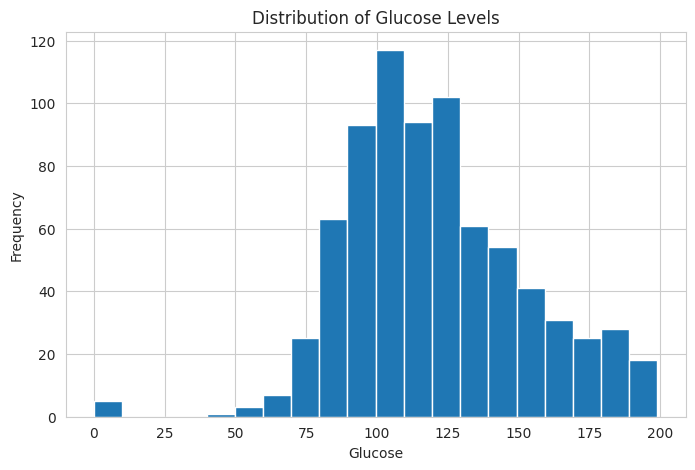

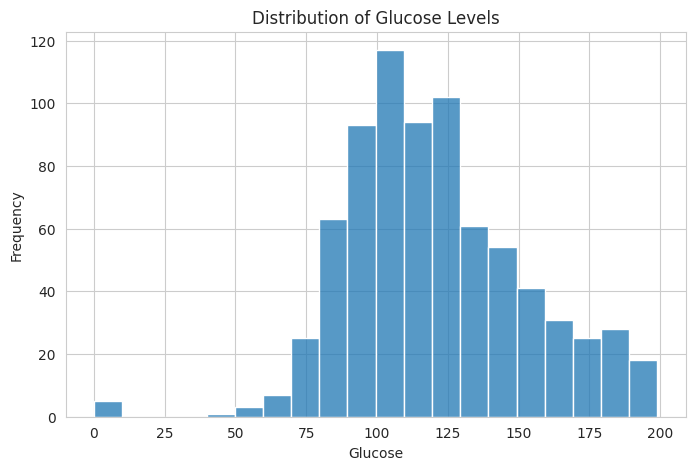

In [17]:
#TASK 3 — Five Chart Types, Histogram

plt.figure(figsize=(8,5))

plt.hist(df['Glucose'], bins=20)

plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose')
plt.ylabel('Frequency')

plt.show()

#Seaborn Version
plt.figure(figsize=(8,5))

sns.histplot(df['Glucose'], bins=20)

plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose')
plt.ylabel('Frequency')

plt.show()

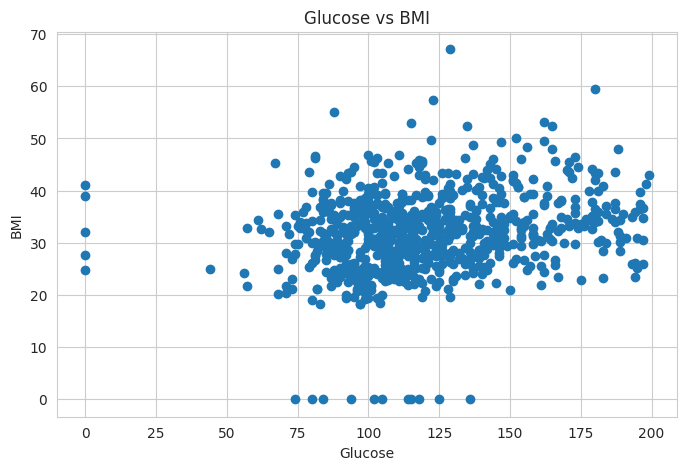

In [18]:
# Scatter Plot
plt.figure(figsize=(8,5))

plt.scatter(df['Glucose'], df['BMI'])

plt.title('Glucose vs BMI')
plt.xlabel('Glucose')
plt.ylabel('BMI')

plt.show()

#Seaborn Version
plt


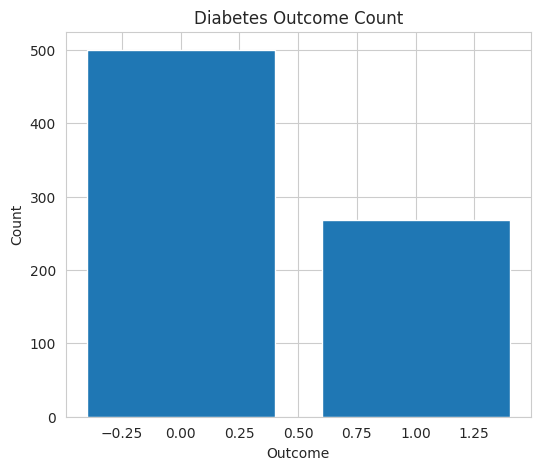

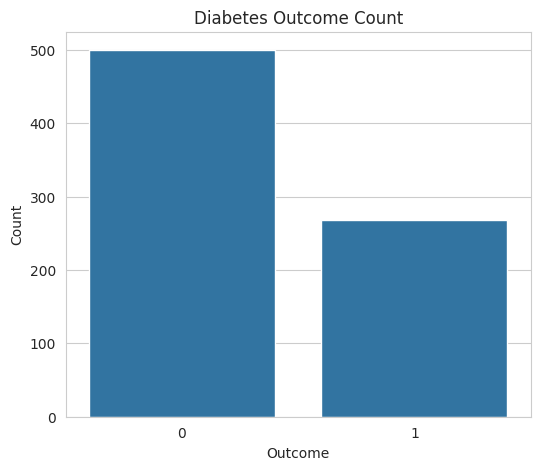

In [19]:
#Bar Chart

outcome_counts = df['Outcome'].value_counts()

plt.figure(figsize=(6,5))

plt.bar(outcome_counts.index, outcome_counts.values)

plt.title('Diabetes Outcome Count')
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.show()

#Seaborn Version
plt.figure(figsize=(6,5))

sns.countplot(x='Outcome', data=df)

plt.title('Diabetes Outcome Count')
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.show()

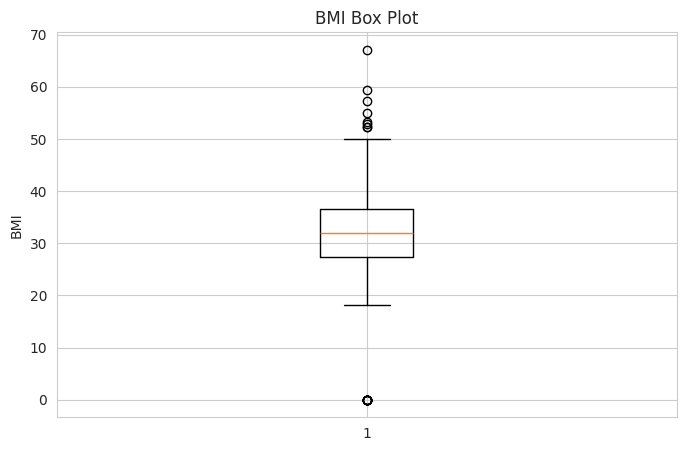

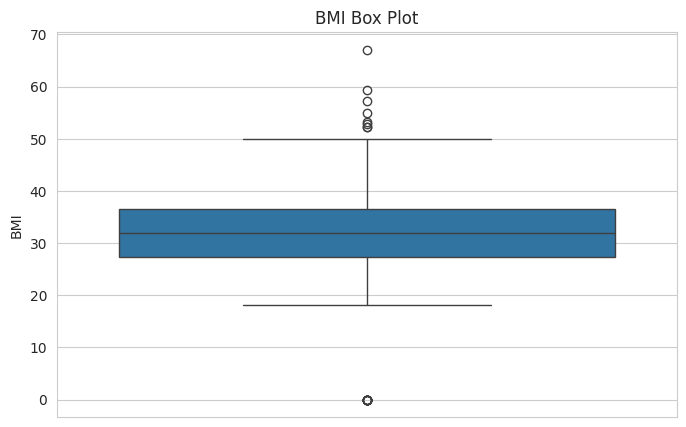

In [20]:
#Box Plot
plt.figure(figsize=(8,5))

plt.boxplot(df['BMI'])

plt.title('BMI Box Plot')
plt.ylabel('BMI')

plt.show()

#Seaborn Version
plt.figure(figsize=(8,5))

sns.boxplot(y='BMI', data=df)

plt.title('BMI Box Plot')
plt.ylabel('BMI')

plt.show()

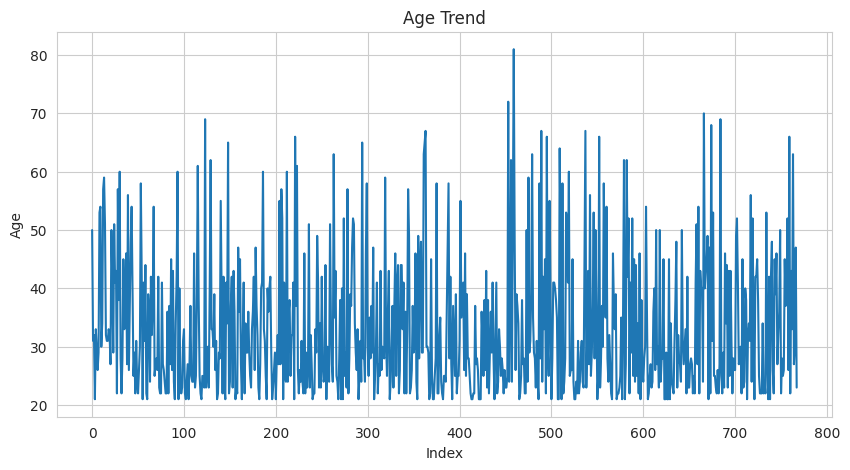

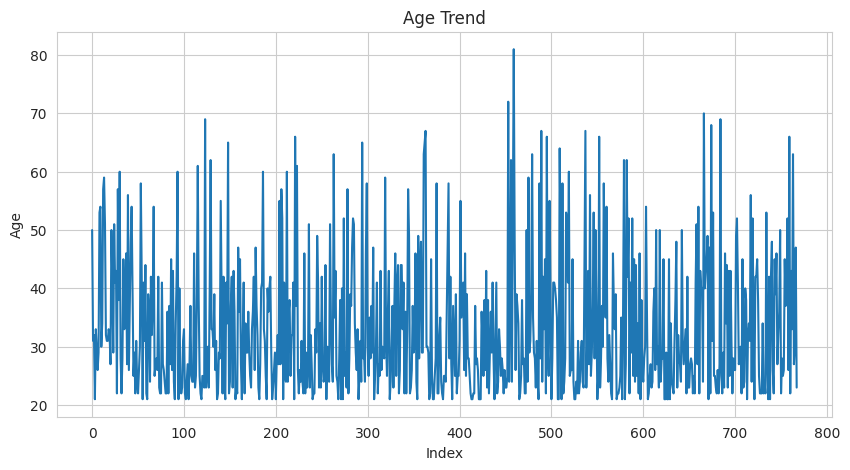

In [21]:
#Line Chart
plt.figure(figsize=(10,5))

plt.plot(df['Age'])

plt.title('Age Trend')
plt.xlabel('Index')
plt.ylabel('Age')

plt.show()

#Seaborn Version
plt.figure(figsize=(10,5))

sns.lineplot(x=df.index, y='Age', data=df)

plt.title('Age Trend')
plt.xlabel('Index')
plt.ylabel('Age')

plt.show()

In [ ]:
## Preferred Visualization Style: I prefer the seaborn visualizations because they are cleaner, more modern, and easier to interpret. Seaborn also provides better default styling and improves the overall presentation of charts.

In [ ]:
# TASK 4 — Data Story

## Three Core Questions
#1.Does a person's glucose level heavily dictate their final diabetes outcome?
#2.Is an elevated Body Mass Index (BMI) visually linked to positive diabetes outcomes?
#3.How does age correlate with glucose spikes across this demographic?

In [ ]:
#Chart 1
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='Glucose', data=df)

plt.title('Glucose Level by Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('Glucose')

plt.show()

#Patients with diabetes had significantly higher glucose levels compared to non-diabetic patients.

In [ ]:
#Chart 2
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='BMI', data=df)

plt.title('BMI by Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('BMI')

plt.show()

#Patients diagnosed with diabetes showed higher average BMI values than non-diabetic patients.

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x='Age', hue='Outcome', bins=20)

plt.title('Age Distribution by Diabetes Outcome')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

#Diabetes cases appeared more frequently among middle-aged and older patients.

In [ ]:
## What I Would Explore Next

#I would further investigate how insulin levels and blood pressure affect diabetes outcomes.
#I would also explore combining this dataset with lifestyle or nutrition datasets to better understand external factors contributing to diabetes.
#Additional features such as exercise habits, diet, and family medical history could improve the analysis.